# Phys255 Assignment 1
# Professor: Dr. Romanowsky
# Student: Se Rang Seo (Simon)
# About: This code uses the data set from : https://pressbooks.online.ucf.edu/osuniversityphysics2/chapter/ohms-law/
## It is a data set about Ohm's Law experimental values: V=IR. It resembles the linear equation: Y=Mx+B where Y=V, I=x, R=M. So, we can perform a linear fit. Since this plot didn't have uncertainties, I used random numbers to generate sample uncertainty values from the example StraightLine.ipynb file.

In [614]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import pandas as pd

In [615]:
iv = pd.read_csv(r"C:\Users\Simon Seo\Downloads\Phys255 ML Assignment 1 Fitting - Sheet1.csv")

x=iv['V']
y=iv['I']

# Defining Base Data

In [616]:
print(iv)

       I   V
0  -2.74 -10
1  -2.25  -9
2  -2.00  -8
3  -1.75  -7
4  -1.50  -6
5  -1.49  -5
6  -1.00  -4
7  -0.51  -3
8  -0.74  -2
9  -0.49  -1
10  0.00   0
11  0.49   1
12  0.50   2
13  0.99   3
14  0.76   4
15  1.01   5
16  1.74   6
17  1.75   7
18  2.00   8
19  2.49   9
20  2.50  10


In [617]:
slopes = np.linspace(0,1,101)
intercepts = np.linspace(0,1,101)

In [618]:
def model(x,m,b):
    return m*x + b

def se(x,m,b,yobs):
    return np.sum((yobs - model(x,m,b))**2)

In [619]:
square_errs = np.zeros((101,101)) #Initialization

for i, m in enumerate(slopes):
    for j,b in enumerate(intercepts):
        square_errs[i,j] = se(x,m,b,y)
        
#or square_errs = np.array([[se(x,m,b,y) for b in intercepts] for m in slopes]) 

In [620]:
np.argmin(square_errs) #index of min; however this corresponds to flattened array

indices = np.unravel_index(square_errs.argmin(), square_errs.shape) #indices of minimum value as a (row, col) pair

print(indices)

bestm, bestb = slopes[indices[0]],intercepts[indices[1]]

(np.int64(26), np.int64(0))


In [621]:
square_errs.shape #check that the array has been built properly

(101, 101)

In [622]:
square_errs

array([[ 51.7586,  51.7655,  51.7766, ...,  72.3974,  72.8159,  73.2386],
       [ 47.8656,  47.8725,  47.8836, ...,  68.5044,  68.9229,  69.3456],
       [ 44.1266,  44.1335,  44.1446, ...,  64.7654,  65.1839,  65.6066],
       ...,
       [402.2066, 402.2135, 402.2246, ..., 422.8454, 423.2639, 423.6866],
       [413.4056, 413.4125, 413.4236, ..., 434.0444, 434.4629, 434.8856],
       [424.7586, 424.7655, 424.7766, ..., 445.3974, 445.8159, 446.2386]],
      shape=(101, 101))

In [623]:
np.argmin(square_errs) #index of min; however this corresponds to flattened array

indices = np.unravel_index(square_errs.argmin(), square_errs.shape) #indices of minimum value as a (row, col) pair

print(indices)

(np.int64(26), np.int64(0))


In [624]:
bestm, bestb = slopes[indices[0]],intercepts[indices[1]]

In [625]:
bestm, bestb #How do they compare to the original ones?

(np.float64(0.26), np.float64(0.0))

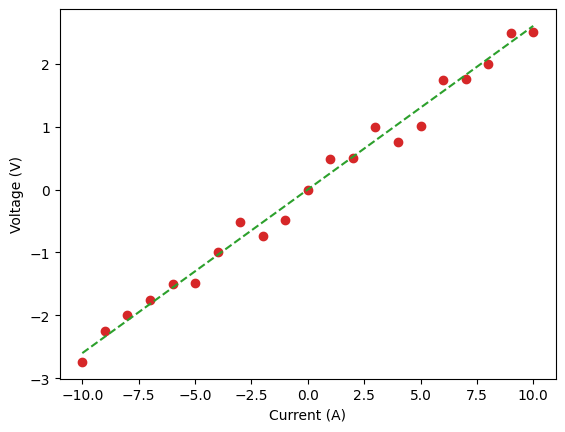

In [626]:
fig2 = plt.figure()
plt.scatter(x,y, c = 'C3')
plt.xlabel('Current (A)')
plt.ylabel('Voltage (V)')
plt.plot(x, bestm * x + bestb, '--', c = 'C2'); 

# Uncertainty and $\chi^2$

In [627]:
np.random.seed(9)

dy = np.random.randn(21)*np.sqrt(0.099) #these are the uncertainties; sign doesn't matter

dy

array([ 3.48798597e-04, -9.11029145e-02, -3.51162064e-01, -4.05346478e-03,
       -1.19048655e-01, -1.51385708e-01, -4.77417110e-01, -1.54449263e-01,
       -7.57283761e-02, -2.03871909e-01,  2.00078457e-01,  5.47515128e-01,
        9.33488805e-02,  2.22610830e-01,  5.73535590e-01,  1.35538311e-01,
        4.85408544e-01, -2.83405300e-01, -4.31453773e-02,  4.08273705e-01,
        2.12469113e-01])

In [628]:
def chi2(x,m,b,yobs,err):
    return np.sum(((yobs - model(x,m,b))**2/err**2))

In [629]:
allchi2 = np.array([[chi2(x,m,b,y,dy) for b in intercepts] for m in slopes]) 

print(allchi2.argmin()) #index of min; however this corresponds to flattened array

indices = np.unravel_index(allchi2.argmin(), allchi2.shape) #indices of minimum value as a (row, col) pair

3167


In [630]:
bestm_werr, bestb_werr = slopes[indices[0]],intercepts[indices[1]]

In [631]:
bestm_werr, bestb_werr

(np.float64(0.31), np.float64(0.36))

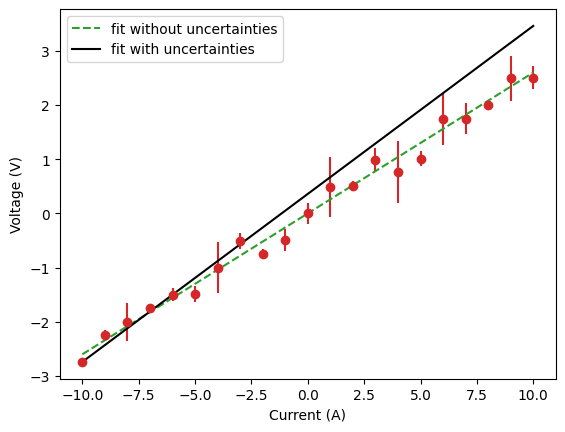

In [632]:
fig4 = plt.figure()

plt.errorbar(x,y, np.abs(dy), marker = 'o', markersize = 6, c = 'C3', linestyle = ' ')

plt.plot(x, bestb + bestm * x, '--', c = 'C2', label = 'fit without uncertainties')

plt.plot(x, bestb_werr + bestm_werr * x, '-', c = 'black', label = 'fit with uncertainties')

plt.xlabel('Current (A)')

plt.ylabel('Voltage (V)')

plt.legend();